In [27]:
import numpy as np
import pandas as pd

In [28]:
# tiempo en minutos
def percent_max(time):
    return 0.8 + 0.1894393 * np.exp(-0.012778 * time) + 0.2989558 * np.exp(-0.1932605 * time)

# velocidad en m/min
def vo2(velocity):
    return -4.60 + 0.182258 * velocity + 0.000104 * velocity**2

def velocity(vo2):
    a = 0.000104
    b = 0.182258
    c = -4.60 - vo2
    discriminant = b**2 - 4*a*c
    if discriminant < 0:
        raise ValueError("No real solution for the given VO2 value.")
    sqrt_discriminant = np.sqrt(discriminant)
    velocity1 = (-b + sqrt_discriminant) / (2*a)
    return velocity1

# tiempo en minutos, distance en metros
def vo2max(distance, time):
    velocity = distance / time
    return vo2(velocity) / percent_max(time)

# tiempo en segundos, distance en metros
def VAM(distance, time):
    time = time / 60  # convertir a minutos
    return velocity(vo2max(distance, time))  / 60  # convertir a m/s

In [38]:
vo2(5.7 * 60)

69.896492

In [36]:
t400 = 54
t800 = 120
t1500 = 255.55

velocidad_400 = 400/t400 * 60 #m/min
velocidad_800 = 800/t800 * 60 #m/min
velocidad_1500 = 1500/t1500 * 60 #m/min

VO2MAX = vo2max(3000, 560/60)

deuda_800_por_minuto = vo2(velocidad_800) - VO2MAX
deuda_1500_por_minuto = vo2(velocidad_1500) - VO2MAX
deuda_400_por_minuto = vo2(velocidad_400) - VO2MAX

deuda_400_total = deuda_400_por_minuto * (t400 / 60)
deuda_800_total = deuda_800_por_minuto * (t800 / 60)
deuda_1500_total = deuda_1500_por_minuto * (t1500 / 60)

print(f"VO2MAX estimado: {VO2MAX:.2f} ml/kg/min")
print(f"Deuda de oxígeno 400m: {deuda_400_por_minuto:.2f} ml/kg/min")
print(f"Deuda de oxígeno 800m: {deuda_800_por_minuto:.2f} ml/kg/min")
print(f"Deuda de oxígeno 1500m: {deuda_1500_por_minuto:.2f} ml/kg/min")

print(f"Deuda total 400m: {deuda_400_total:.2f} ml/kg")
print(f"Deuda total 800m: {deuda_800_total:.2f} ml/kg")
print(f"Deuda total 1500m: {deuda_1500_total:.2f} ml/kg")



VO2MAX estimado: 63.62 ml/kg/min
Deuda de oxígeno 400m: 33.32 ml/kg/min
Deuda de oxígeno 800m: 21.32 ml/kg/min
Deuda de oxígeno 1500m: 8.86 ml/kg/min
Deuda total 400m: 29.99 ml/kg
Deuda total 800m: 42.64 ml/kg
Deuda total 1500m: 37.76 ml/kg


In [30]:
K = 0.013

def speed(aerobic_speed, anaerobic_speed, time):
    return aerobic_speed + (anaerobic_speed - aerobic_speed) * np.exp(-K * time)

def maximal_sprint_speed(aerobic_speed, time, distance):
    speed = distance / time
    return (speed - aerobic_speed) / np.exp(-K * time) + aerobic_speed

def anaerobic_speed_reserve(distance_1, time_1, distance_2, time_2):
    speed_1 = distance_1 / time_1
    speed_2 = distance_2 / time_2
    speed_diff = speed_1 - speed_2
    exp_diff = np.exp(-K * time_1) - np.exp(-K * time_2)
    return speed_diff / exp_diff

def aerobic_speed(distance, time, ASR):
    speed = distance / time
    return speed - ASR * np.exp(-K * time)

In [31]:
VAM = VAM(3000, 579)
MSS = maximal_sprint_speed(VAM, 9.58, 100)  # ejemplo de uso
ASR = MSS - VAM
print(f"VAM: {VAM:.2f} m/s, MSS: {MSS:.2f} m/s, ASR: {ASR:.2f} m/s")

VAM: 5.12 m/s, MSS: 11.14 m/s, ASR: 6.02 m/s


In [32]:
# ASR = anaerobic_speed_reserve(100, 12.5, 400, 54)
# VAM = aerobic_speed(800, 120, ASR)
# MSS = VAM + ASR
# # imprimir resultados en km/h
# print(f"VAM: {VAM*3.6:.2f} km/h, MSS: {MSS*3.6:.2f} km/h, ASR: {ASR*3.6:.2f} km/h")

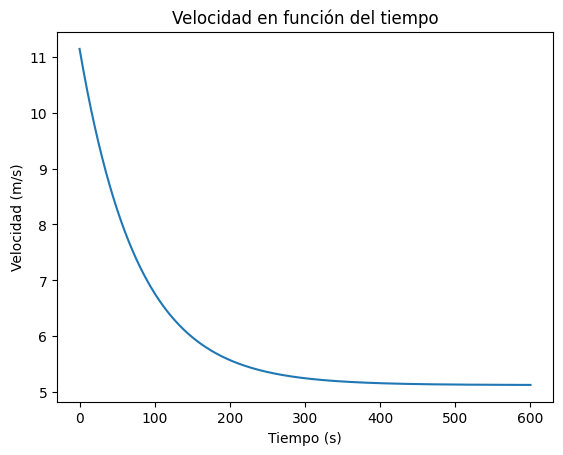

In [33]:
import matplotlib.pyplot as plt
times = np.linspace(0, 600, 600)  # tiempos de 0 a 300 segundos
speeds = speed(VAM, MSS, times)
plt.plot(times, speeds)
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad (m/s)')
plt.title('Velocidad en función del tiempo')
plt.show()